In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import xgboost as xgb


In [40]:
spotify1 = pd.read_csv('spotify1.csv', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], index_col=False)
spotify2 = pd.read_csv('spotify2.csv', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], index_col=False) 
spotify3 = pd.read_csv('spotify3.csv', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], index_col=False)
spotify4 = pd.read_csv('spotify4.csv', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], index_col=False)
#check if the columns are the same, then printing column names
print(spotify1.columns.equals(spotify2.columns))
print(spotify2.columns.equals(spotify3.columns))
print(spotify3.columns.equals(spotify4.columns))
print(spotify4.columns)
#looking at shape of the dataframes
print(spotify1.shape)
print(spotify2.shape)
print(spotify3.shape)
print(spotify4.shape)

True
True
True
Index(['track_name', 'artist.s._name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_.', 'valence_.', 'energy_.',
       'acousticness_.', 'instrumentalness_.', 'liveness_.', 'speechiness_.',
       'cover_url'],
      dtype='object')
(381, 25)
(286, 25)
(191, 25)
(95, 25)


In [41]:
#concatenating the dataframes and double checking the shape of the concatenated dataframe
df = pd.concat([spotify1, spotify2, spotify3, spotify4], ignore_index=True)
print(381+286+191+95)
print(df.shape)
print(df.dtypes)
df.describe()

953
(953, 25)
track_name              object
artist.s._name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_.           int64
valence_.                int64
energy_.                 int64
acousticness_.           int64
instrumentalness_.       int64
liveness_.               int64
speechiness_.            int64
cover_url               object
dtype: object


,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_.,valence_.,energy_.,acousticness_.,instrumentalness_.,liveness_.,speechiness_.
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [42]:
df = df.rename(columns={'danceability_.':'danceability', 'valence_.':'valence', 'energy_.':'energy',
       'acousticness_.':'acousticness', 'instrumentalness_.':'instrumentalness', 'liveness_.':'liveness', 'speechiness_.':'speechiness'})

In [43]:
#checking why numeric values are importing as objects
print(df['streams'][~df['streams'].apply(lambda x: str(x).isdigit())])
print(df['in_deezer_playlists'][~df['in_deezer_playlists'].apply(lambda x: str(x).isdigit())])
print(df['in_shazam_charts'][~df['in_shazam_charts'].apply(lambda x: str(x).isdigit())])


450    BPM110KeyAModeMajorDanceability53Valence75Ener...
Name: streams, dtype: object
6      5,451
10     1,481
21     4,534
31     6,591
46     1,509
       ...  
905    2,655
909    2,094
915    2,445
933    1,066
943    5,567
Name: in_deezer_playlists, Length: 79, dtype: object
44       NaN
53       NaN
97       NaN
113      NaN
116      NaN
       ...  
856      0.0
857      NaN
864    1,173
907    1,281
909      NaN
Name: in_shazam_charts, Length: 230, dtype: object


In [44]:
#fixing the numeric variables that are importing as objects
#Streams only has one non-numeric value, so we can replace it with NaN, then convert to numeric
df.loc[450, 'streams'] = np.nan
df['streams'] = pd.to_numeric(df['streams'], errors='coerce').astype('Int64')
#in_deezer_playlists and in_shazam_charts have commas and non-numeric values. Replace those with NaN, then convert to numeric
df['in_deezer_playlists'] = df['in_deezer_playlists'].replace(',', '', regex=True)
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists']).astype('Int64')
df['in_shazam_charts'] = df['in_shazam_charts'].replace(',', '', regex=True)
df['in_shazam_charts'] = df['in_shazam_charts'].replace(to_replace=np.nan, value=None)
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce').astype('Int64')

#looking at null values in these columns
print(df['streams'].isnull().sum())
print(df['in_deezer_playlists'].isnull().sum())
print(df['in_shazam_charts'].isnull().sum())
#checking the data types of the columns again
print(df.dtypes)

1
0
50
track_name              object
artist.s._name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                  Int64
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists      Int64
in_deezer_charts         int64
in_shazam_charts         Int64
bpm                      int64
key                     object
mode                    object
danceability             int64
valence                  int64
energy                   int64
acousticness             int64
instrumentalness         int64
liveness                 int64
speechiness              int64
cover_url               object
dtype: object


In [45]:
#looking at summary statistics after cleaning columns
print(df.describe())

       artist_count  released_year  released_month  released_day  \
count    953.000000     953.000000      953.000000    953.000000   
mean       1.556139    2018.238195        6.033578     13.930745   
std        0.893044      11.116218        3.566435      9.201949   
min        1.000000    1930.000000        1.000000      1.000000   
25%        1.000000    2020.000000        3.000000      6.000000   
50%        1.000000    2022.000000        6.000000     13.000000   
75%        2.000000    2022.000000        9.000000     22.000000   
max        8.000000    2023.000000       12.000000     31.000000   

       in_spotify_playlists  in_spotify_charts           streams  \
count            953.000000         953.000000             952.0   
mean            5200.124869          12.009444  514137424.939076   
std             7897.608990          19.575992  566856949.038883   
min               31.000000           0.000000            2762.0   
25%              875.000000           0.000000 

<Axes: >

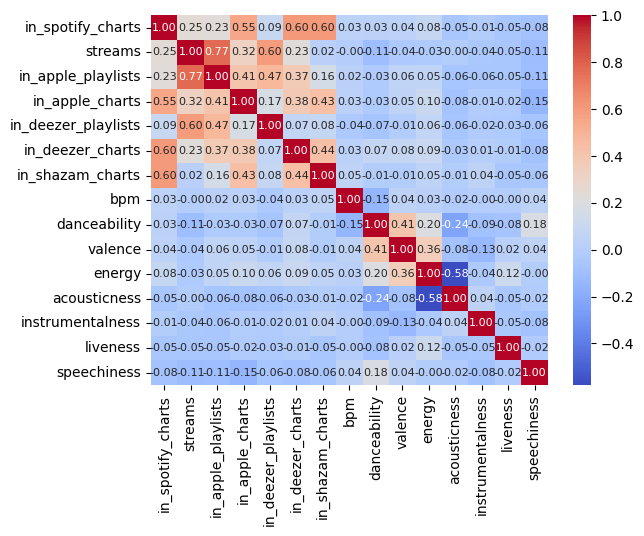

In [46]:
plotdf = df[['in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'danceability', 'valence', 'energy',
       'acousticness', 'instrumentalness', 'liveness', 'speechiness']]
sns.heatmap(plotdf.corr(), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 8})
#looking at the heatmap we can see that there is a strong correlation between appropriate variables, such as in charts for spotify and apple. If higher in playlist on one app, likely to be in more playlists in other apps
#we also see that there is a correlation between target variables.
#Valence, energy, and danceability have higher correlations with each other. Acousticness is negatively correlated with those variables.



<Axes: >

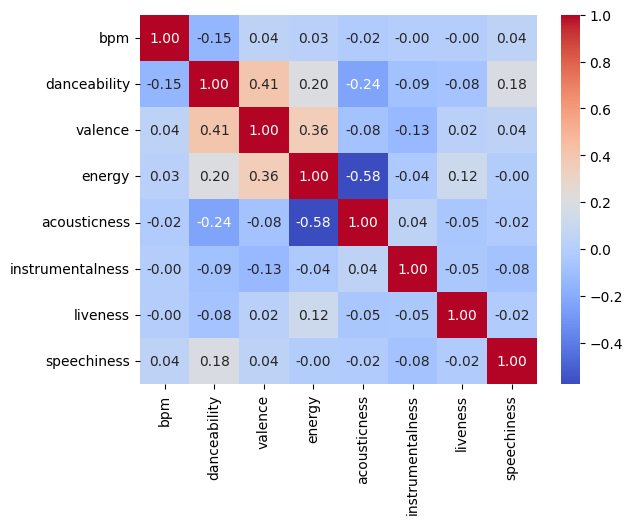

In [47]:
#better look at the correlation between the target variables
plotdf1= df[['bpm', 'danceability', 'valence', 'energy',
       'acousticness', 'instrumentalness', 'liveness', 'speechiness']]
sns.heatmap(plotdf1.corr(), annot=True, fmt='.2f', cmap='coolwarm')

(array([1920., 1940., 1960., 1980., 2000., 2020., 2040.]),
 [Text(1920.0, 0, '1920'),
  Text(1940.0, 0, '1940'),
  Text(1960.0, 0, '1960'),
  Text(1980.0, 0, '1980'),
  Text(2000.0, 0, '2000'),
  Text(2020.0, 0, '2020'),
  Text(2040.0, 0, '2040')])

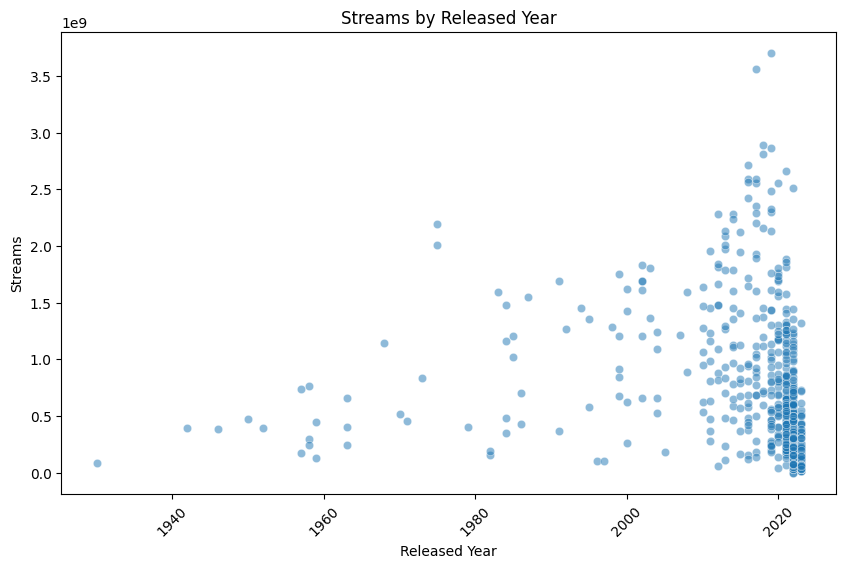

In [48]:
#creating a scatterplot looking at released_year and streams. 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='released_year', y='streams', alpha=0.5)
plt.title('Streams by Released Year')
plt.xlabel('Released Year')
plt.ylabel('Streams')
plt.xticks(rotation=45)
#due to the non-linear relationship, linear regression will not be appropriate for this data. Decision tree or random forest regression may be more appropriate.


(array([ 99., 152., 131., 102.,  77.,  49.,  42.,  28.,  31.,  31.,  20.,
         20.,  12.,  10.,  12.,  17.,  15.,  13.,   7.,  14.,   2.,   9.,
          8.,   5.,   8.,   3.,   4.,   2.,   4.,   3.,   4.,   3.,   1.,
          2.,   4.,   2.,   1.,   1.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.]),
 array([2.76200000e+03, 7.40806082e+07, 1.48158454e+08, 2.22236301e+08,
        2.96314147e+08, 3.70391993e+08, 4.44469839e+08, 5.18547686e+08,
        5.92625532e+08, 6.66703378e+08, 7.40781224e+08, 8.14859071e+08,
        8.88936917e+08, 9.63014763e+08, 1.03709261e+09, 1.11117046e+09,
        1.18524830e+09, 1.25932615e+09, 1.33340399e+09, 1.40748184e+09,
        1.48155969e+09, 1.55563753e+09, 1.62971538e+09, 1.70379323e+09,
        1.77787107e+09, 1.85194892e+09, 1.92602676e+09, 2.00010461e+09,
        2.07418246e+09, 2.14826030e+09, 2.22233815e+09, 2.29641600e+09,
        2.37049384e+09, 2.44457169e+09, 2.51864953e+09, 2.59272738e+09,
        2.

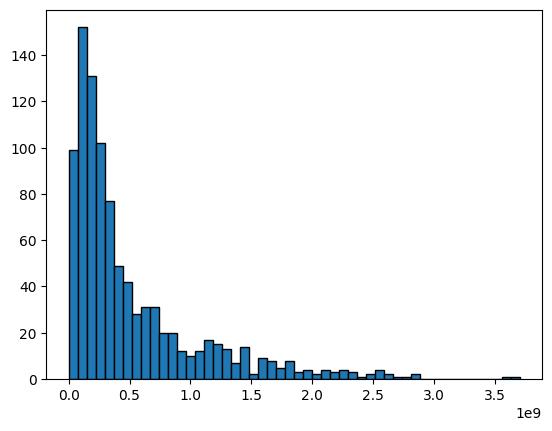

In [49]:
plt.hist(df['streams'], bins=50, edgecolor='black')
#streams has a non-normal distribution

In [50]:
#looking to add these in later. Needs recoding. 
print(df['key'].value_counts())
print(df['mode'].value_counts())
#due to the large number of unique values in key, we will not be using it in the model since dummy coding would create too many variables.
#key doe

key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64
mode
Major    550
Minor    403
Name: count, dtype: int64


In [51]:
#dropping rows with na in target variables.
df = df.dropna(subset=['streams','bpm', 'danceability', 'valence', 'energy',
       'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'released_year'], how='any', axis=0)

In [52]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

Mean Absolute Error:
240287696.28456947
Mean Squared Error:
1.2741137873449578e+17
Root Mean Squared Error:
356947305.26296985
R2 Score:
0.31252482329112086


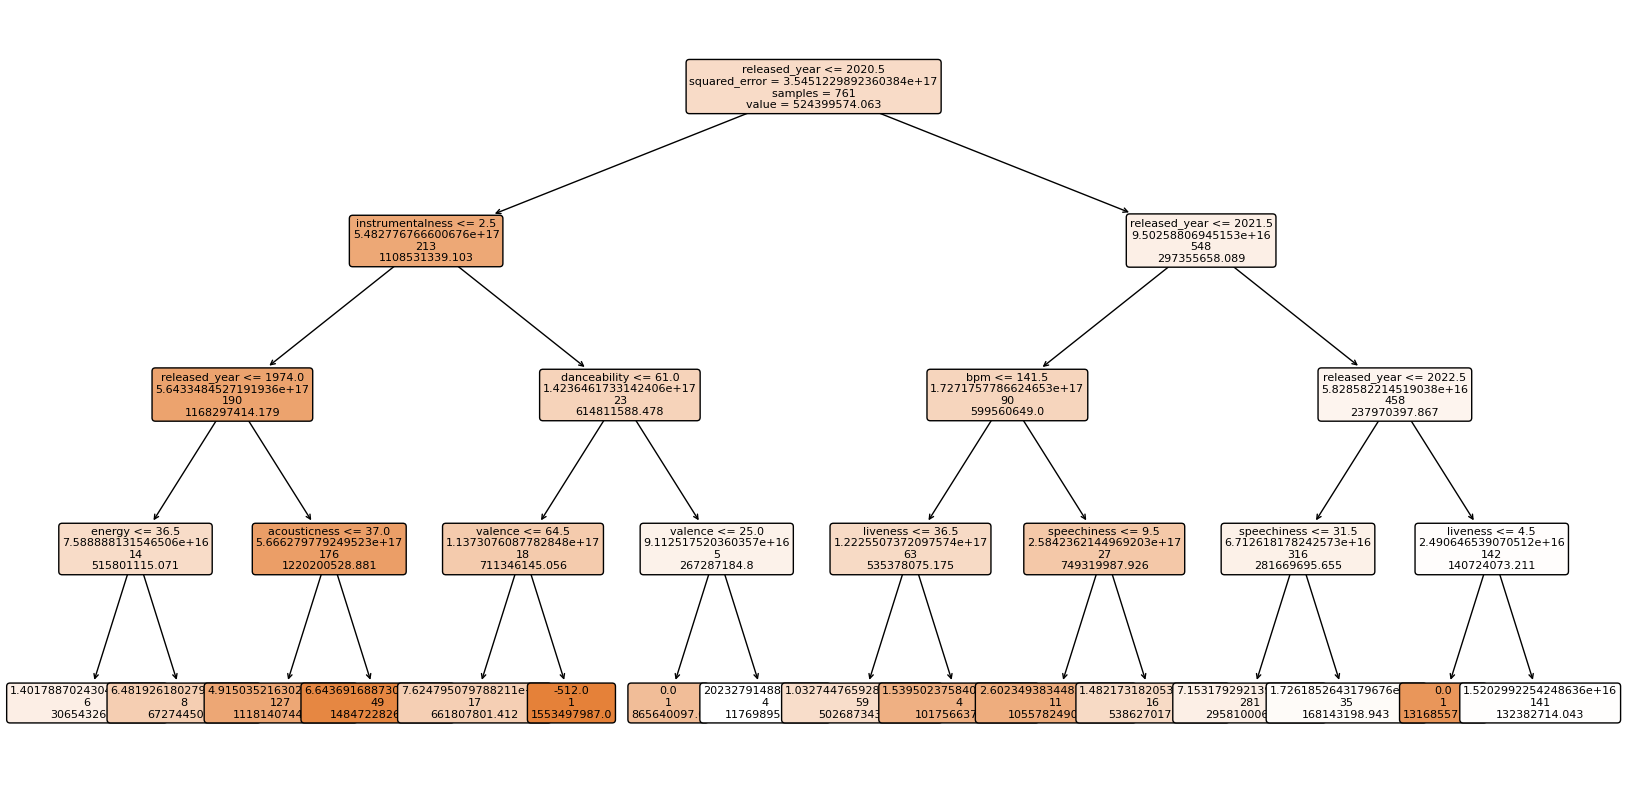

|--- released_year <= 2020.50
|   |--- instrumentalness <= 2.50
|   |   |--- released_year <= 1974.00
|   |   |   |--- energy <= 36.50
|   |   |   |   |--- value: [306543260.50]
|   |   |   |--- energy >  36.50
|   |   |   |   |--- value: [672744506.00]
|   |   |--- released_year >  1974.00
|   |   |   |--- acousticness <= 37.00
|   |   |   |   |--- value: [1118140744.75]
|   |   |   |--- acousticness >  37.00
|   |   |   |   |--- value: [1484722826.53]
|   |--- instrumentalness >  2.50
|   |   |--- danceability <= 61.00
|   |   |   |--- valence <= 64.50
|   |   |   |   |--- value: [661807801.41]
|   |   |   |--- valence >  64.50
|   |   |   |   |--- value: [1553497987.00]
|   |   |--- danceability >  61.00
|   |   |   |--- valence <= 25.00
|   |   |   |   |--- value: [865640097.00]
|   |   |   |--- valence >  25.00
|   |   |   |   |--- value: [117698956.75]
|--- released_year >  2020.50
|   |--- released_year <= 2021.50
|   |   |--- bpm <= 141.50
|   |   |   |--- liveness <= 36.50
|  

In [53]:
X= df[['bpm', 'danceability', 'valence', 'energy',
       'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'released_year']]
y = df['streams']

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

model1 = DecisionTreeRegressor(random_state=42, max_depth=4)
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
print('Mean Absolute Error:', sk.metrics.mean_absolute_error(y_test, y_pred), 'Mean Squared Error:', sk.metrics.mean_squared_error(y_test, y_pred),
      'Root Mean Squared Error:', np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred)), 
      'R2 Score:', sk.metrics.r2_score(y_test, y_pred), sep='\n')
model1_stats = pd.DataFrame({'Model': 'model1', 
                            'MAE': [sk.metrics.mean_absolute_error(y_test, y_pred)], 
                            'MSE': [sk.metrics.mean_squared_error(y_test, y_pred)], 
                            'RMSE': [np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))], 
                            'R2 Score': [sk.metrics.r2_score(y_test, y_pred)]})


# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model1, feature_names=X.columns, filled=True, fontsize=8, rounded=True, label='root')
plt.show()

#looking at decision tree as text
print(export_text(model1, feature_names=X.columns, decimals=2, max_depth=4))

In [76]:
#Why is year released so important? Looking at target variables 
#some prliminary looking at data. Grouping by decade to see if that affects target variables
df['decade'] = df['released_year'].apply(lambda year: 'Unknown' if pd.isna(year) else f'{(year // 10) * 10}s')
df.groupby(['decade'])[['bpm', 'danceability', 'valence', 'energy','acousticness', 
          'instrumentalness', 'liveness', 'speechiness','streams']].mean().round(2).sort_values(by='streams', ascending=False)
#There are some differences in music features by decade, which is expected. How much will this affect the model?
#notice that decade does affect streams the most, probably why realeased_year is highly valued in the model. 


,bpm,danceability,valence,energy,acousticness,instrumentalness,liveness,speechiness,streams
decade,,,,,,,,,
2010s,121.28,60.56,44.50,61.74,29.32,3.78,16.01,7.32,1179976672.73
2000s,122.15,64.95,45.35,71.25,14.20,0.25,17.30,10.85,1158798596.5
1970s,107.17,47.67,51.00,59.50,37.33,0.00,31.33,3.67,1071526491.17
1990s,114.29,64.64,46.50,67.36,13.14,3.00,19.36,8.86,972545174.14
1980s,120.83,63.42,63.33,69.67,24.00,4.75,18.17,4.33,861096276.42
1960s,134.00,46.25,67.75,70.75,40.75,0.00,16.25,3.75,614247748.0
1950s,135.89,64.22,84.22,38.11,78.67,0.00,17.56,4.78,408086944.11
1940s,117.50,29.50,20.50,20.00,87.50,0.00,25.50,3.50,392681680.0
2020s,122.92,68.88,52.49,64.88,26.34,1.13,18.58,11.00,342050064.07


In [55]:
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
#looking at how different decades affect the target variables
#using ANOVA to see if there are significant differences between the means of the different decades, just for fun
for feature in ['bpm', 'danceability', 'valence', 'energy','acousticness', 
          'instrumentalness', 'liveness', 'speechiness','streams']:
    model = sm.ols(f'{feature} ~ decade', data=df).fit()
    anova_results = anova_lm(model, typ=2)
    print(f'ANOVA results for {feature} by decade:')
    print(anova_results)
    print('\n')
#There are significant differences in target variables by decade, would be interesting to look futher and what combination of 
#features defines each decade. Can pursue this later.


ANOVA results for bpm by decade:
                 sum_sq     df         F    PR(>F)
decade      4989.730343    9.0  0.701672  0.707787
Residual  744305.537514  942.0       NaN       NaN


ANOVA results for danceability by decade:
                 sum_sq     df         F        PR(>F)
decade     16002.688904    9.0  8.929148  5.293672e-13
Residual  187582.074751  942.0       NaN           NaN


ANOVA results for valence by decade:
                 sum_sq     df         F    PR(>F)
decade     23513.216695    9.0  4.914174  0.000002
Residual  500806.462927  942.0       NaN       NaN


ANOVA results for energy by decade:
                 sum_sq     df         F        PR(>F)
decade     13334.127266    9.0  5.640874  1.264383e-07
Residual  247415.317062  942.0       NaN           NaN


ANOVA results for acousticness by decade:
                 sum_sq     df         F        PR(>F)
decade     39969.411391    9.0  6.937918  9.903542e-10
Residual  602985.679996  942.0       NaN           NaN



In [56]:
#looking at just decade and streams to see how different decades affect streams
import statsmodels.stats.multicomp as mc
tukeyresults = mc.pairwise_tukeyhsd(df['streams'], df['decade'], alpha=0.05)
print(tukeyresults)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
group1 group2     meandiff    p-adj       lower            upper      reject
----------------------------------------------------------------------------
 1930s  1940s     302083163.0    1.0 -1496602668.1708 2100768994.1708  False
 1930s  1950s  317488427.1111 0.9997 -1230573854.9298  1865550709.152  False
 1930s  1960s     523649231.0 0.9916 -1118318774.9953 2165617236.9953  False
 1930s  1970s  980927974.1667 0.6268  -605363824.5045 2567219772.8379  False
 1930s  1980s  770497759.4167 0.8489  -758091265.9105 2299086784.7438  False
 1930s  1990s  881946657.1429 0.7095  -638220325.9911 2402113640.2768  False
 1930s  2000s    1068200079.5 0.4224  -436688455.7339 2573088614.7339  False
 1930s  2010s 1089378155.7285 0.3611  -384097633.7247 2562853945.1817  False
 1930s  2020s  251451547.0682 0.9999  -1218170730.548 1721073824.6844  False
 1940s  1950s   15405264.1111    1.0  -1132668451.289 1163478979.5112  False

In [57]:
#returning from sidetrack. Looking at feature selection to slim model down
from sklearn.feature_selection import f_regression
f_statistics, p_values = f_regression(X, y)
feature_scores = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_statistics, 'p-value': p_values})
feature_scores = feature_scores.sort_values(by='F-Statistic', ascending=False)
print(feature_scores)
#released_year, speechiness, and danceability are the most important features.


            Feature  F-Statistic       p-value
8     released_year    53.454011  5.615320e-13
7       speechiness    12.140970  5.157880e-04
1      danceability    10.683914  1.119498e-03
6          liveness     2.224868  1.361363e-01
5  instrumentalness     1.919290  1.662601e-01
2           valence     1.586486  2.081383e-01
3            energy     0.645184  4.220408e-01
4      acousticness     0.019107  8.900898e-01
0               bpm     0.005646  9.401179e-01


In [58]:
#Creating For Loop to test different max_depth values
#Figuring out what is the best max_depth for the model
model_stats = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])
X= df[['released_year', 'speechiness', 'danceability', 'liveness',
       'instrumentalness', 'valence', 'energy', 'acousticness', 'bpm']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
for branch in range(2, 11):
    model = DecisionTreeRegressor(random_state=42, max_depth=branch)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    models = pd.DataFrame({'Model': f'model{branch}',
                            'MAE': sk.metrics.mean_absolute_error(y_test, y_pred), 
                            'MSE': sk.metrics.mean_squared_error(y_test, y_pred), 
                            'RMSE': np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred)), 
                            'R2 Score': sk.metrics.r2_score(y_test, y_pred)}, index=[0])
    model_stats = pd.concat([model_stats, models], ignore_index=True)
print(model_stats.sort_values(by='R2 Score', ascending=False))    


     Model           MAE           MSE          RMSE  R2 Score
1   model3  2.329855e+08  1.224953e+17  3.499934e+08  0.339050
2   model4  2.428742e+08  1.293459e+17  3.596469e+08  0.302087
0   model2  2.509086e+08  1.373061e+17  3.705484e+08  0.259136
3   model5  2.587491e+08  1.646326e+17  4.057495e+08  0.111690
4   model6  2.656074e+08  1.703384e+17  4.127207e+08  0.080903
5   model7  2.913668e+08  2.075287e+17  4.555531e+08 -0.119765
7   model9  3.129529e+08  2.343943e+17  4.841429e+08 -0.264724
6   model8  3.029234e+08  2.366818e+17  4.864996e+08 -0.277067
8  model10  3.065798e+08  2.409074e+17  4.908231e+08 -0.299867


C:\Users\Liam\AppData\Local\Temp\ipykernel_14888\1157837960.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_stats = pd.concat([model_stats, models], ignore_index=True)


In [59]:
def forward_selection(X, y, features, model, scoring, selection_metric='R2'):
    """
    Perform forward selection for features in model based on R2. Other scoring metrics are available but not used for 
    feature selection.
    Args:
        X: (pd.DataFrame) DataFrame of features
        y: (pd.Series) Series of target variable
        features: (list) list of features to select from
        model: (object) model to use for selection
        scoring: (list) list of scoring metric to use for selection (options: 'MAE', 'MSE', 'RMSE', 'R2')
        selection_metric: (str) metric to use for selection (default: 'R2') (options: 'MAE', 'MSE', 'RMSE', 'R2')

     Returns:
        selected_features: (list) list of selected features
    """
    selected_features = []
    remaining_features = list(features)
    R2_best_score = 0
    best_score = np.inf
    score_dict = {}
    while remaining_features:
        best_feature = None
        R2_current_best_score = R2_best_score
        current_best_score = best_score
        for feature in remaining_features:
            currect_features = selected_features + [feature]
            X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X[currect_features], y, test_size=0.2, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            for score in scoring:
                if score == 'MAE':
                    MAE_value = sk.metrics.mean_absolute_error(y_test, y_pred)
                    score_dict['MAE'] = MAE_value
                elif score == 'MSE':
                    MSE_value = sk.metrics.mean_squared_error(y_test, y_pred)
                    score_dict['MSE'] = MSE_value
                elif score == 'RMSE':
                    RMSE_value = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
                    score_dict['RMSE'] = RMSE_value
                elif score == 'R2':
                    R2_value = sk.metrics.r2_score(y_test, y_pred)
                    score_dict['R2'] = R2_value
        
            if selection_metric == 'R2':
                if score_dict['R2'] > R2_current_best_score:
                    R2_current_best_score = score_dict['R2']
                    best_feature = feature
            elif selection_metric == 'MAE':
                if score_dict['MAE'] < current_best_score:
                    current_best_score = score_dict['MAE']
                    #added in for testing
                    #print(current_best_score)
                    best_feature = feature
            elif selection_metric == 'MSE':
                if score_dict['MSE'] < current_best_score:
                    current_best_score = score_dict['MSE']
                    #added in for testing
                    #print(current_best_score)
                    best_feature = feature
            elif selection_metric == 'RMSE':
                if score_dict['RMSE'] < current_best_score:
                    current_best_score = score_dict['RMSE']
                    #added in for testing
                    #print(current_best_score)
                    best_feature = feature
        if best_feature is None:
           break
        selected_features.append(best_feature)
        print(f'Selected feature: {best_feature}')
        remaining_features.remove(best_feature)
        if selection_metric == 'R2':
            if R2_current_best_score > R2_best_score:
                R2_best_score = R2_current_best_score

        else:
            if current_best_score < best_score:
                best_score = current_best_score
    return selected_features, score_dict
    
#Not working perfectly, seems like too many features for R2 and skipping intial feature for other metrics. 
#By this logic, released_year should be a forced selection, but it is not.
#fixed R2 logic
#fixed other metrics logic
              


In [60]:
#Forward_selection with R2 as the selection metric
X= df[['released_year', 'speechiness', 'danceability', 'liveness',
       'instrumentalness', 'valence', 'energy', 'acousticness', 'bpm']]
y = df['streams']
#using forward selection to find the best features for the model. Set max_depth to 3 since that was the best performing model.
forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), ['MAE', 'MSE', 'RMSE', 'R2'])
#shows that only released_year, bpm, and danceability is important for the model. Not what we expected. 
#Different features compared to the sklearn f-regression feature selection function. 

Selected feature: released_year
Selected feature: bpm
Selected feature: danceability


(['released_year', 'bpm', 'danceability'],
 {'MAE': 232858831.10984963,
  'MSE': 1.205054981689691e+17,
  'RMSE': 347139018.5055104,
  'R2': 0.34978696980637936})

In [61]:
#forward_selection with other selection metrics
for metric in ['MAE', 'MSE', 'RMSE']:
    selected_features, score_dict = forward_selection(X, y, X.columns.tolist(), DecisionTreeRegressor(random_state=42, max_depth=3), [metric], selection_metric=metric)
    print(f"Selected features for {metric}: {selected_features}")
    print(f"Scores: {score_dict}")

"""print(f"MSE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), ['MAE', 'MSE', 'RMSE', 'R2'], selection_metric='MAE')}")
print("")
print(f"MAE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), ['MAE', 'MSE', 'RMSE', 'R2'], selection_metric='MAE')}")
print("")
print(f"RMSE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), ['MAE', 'MSE', 'RMSE', 'R2'], selection_metric='RMSE')}")
"""#This shows that the features are different depending on the selection metric.

Selected feature: released_year
Selected feature: bpm
Selected features for MAE: ['released_year', 'bpm']
Scores: {'MAE': 232833226.46070206}
Selected feature: released_year
Selected feature: bpm
Selected feature: danceability
Selected features for MSE: ['released_year', 'bpm', 'danceability']
Scores: {'MSE': 1.205054981689691e+17}
Selected feature: released_year
Selected feature: bpm
Selected feature: danceability
Selected features for RMSE: ['released_year', 'bpm', 'danceability']
Scores: {'RMSE': 347139018.5055104}


'print(f"MSE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), [\'MAE\', \'MSE\', \'RMSE\', \'R2\'], selection_metric=\'MAE\')}")\nprint("")\nprint(f"MAE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), [\'MAE\', \'MSE\', \'RMSE\', \'R2\'], selection_metric=\'MAE\')}")\nprint("")\nprint(f"RMSE {forward_selection(X,y,X.columns.tolist(),DecisionTreeRegressor(random_state=42, max_depth=3), [\'MAE\', \'MSE\', \'RMSE\', \'R2\'], selection_metric=\'RMSE\')}")\n'

In [62]:
#creating final model with max_depth of 3 and selected features (released_year, bpm, danceability,
#and speechiness [from f-regression])
X = df[['released_year', 'bpm', 'danceability', 'speechiness']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
final_model = DecisionTreeRegressor(random_state=42, max_depth=3)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print('Final Model Mean Absolute Error:', sk.metrics.mean_absolute_error(y_test, y_pred), 
      'Final Model Mean Squared Error:', sk.metrics.mean_squared_error(y_test, y_pred),
      'Final Model Root Mean Squared Error:', np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred)), 
      'Final Model R2 Score:', sk.metrics.r2_score(y_test, y_pred), sep='\n')

Final Model Mean Absolute Error:
232858831.10984963
Final Model Mean Squared Error:
1.205054981689691e+17
Final Model Root Mean Squared Error:
347139018.5055104
Final Model R2 Score:
0.34978696980637936


XGBoost Mean Absolute Error:
271142782.63350785
XGBoost Mean Squared Error:
1.6199638008741728e+17
XGBoost Root Mean Squared Error:
402487739.0522813
XGBoost R2 Score:
0.12591409705353362


<Figure size 2000x1000 with 0 Axes>

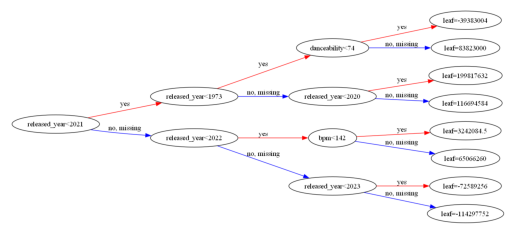

0:[released_year<2021] yes=1,no=2,missing=2
	1:[released_year<1973] yes=3,no=4,missing=4
		3:[danceability<74] yes=7,no=8,missing=8
			7:leaf=-39383004
			8:leaf=83823000
		4:[released_year<2020] yes=9,no=10,missing=10
			9:leaf=199817632
			10:leaf=116694584
	2:[released_year<2022] yes=5,no=6,missing=6
		5:[bpm<142] yes=11,no=12,missing=12
			11:leaf=3242084.5
			12:leaf=65066260
		6:[released_year<2023] yes=13,no=14,missing=14
			13:leaf=-72589256
			14:leaf=-114297752



In [63]:
#Starting to look at XGBoost
from sklearn.metrics import RocCurveDisplay
X = df[['released_year', 'bpm', 'danceability', 'speechiness']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', n_estimators= 100, learning_rate=.3, random_state=42, max_depth=3)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print('XGBoost Mean Absolute Error:', sk.metrics.mean_absolute_error(y_test, y_pred_xgb), 
      'XGBoost Mean Squared Error:', sk.metrics.mean_squared_error(y_test, y_pred_xgb),
      'XGBoost Root Mean Squared Error:', np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_xgb)), 
      'XGBoost R2 Score:', sk.metrics.r2_score(y_test, y_pred_xgb), sep='\n')
plt.figure(figsize=(20, 10))
xgb.plot_tree(xgb_model, tree_idx=0, rankdir='LR',)
plt.show()
print(xgb_model.get_booster().get_dump()[0])  # Print the first tree in the model

XGBoost Mean Absolute Error:
234056824.31413612
XGBoost Mean Squared Error:
1.3166692269021019e+17
XGBoost Root Mean Squared Error:
362859370.4043072
XGBoost R2 Score:
0.2895631313134869


<Figure size 2000x1000 with 0 Axes>

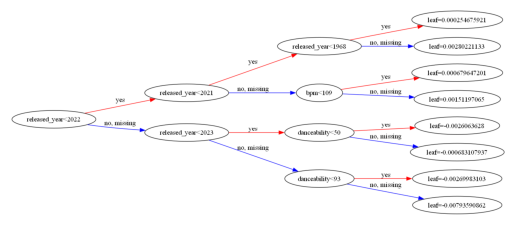

0:[released_year<2022] yes=1,no=2,missing=2
	1:[released_year<2021] yes=3,no=4,missing=4
		3:[released_year<1968] yes=7,no=8,missing=8
			7:leaf=0.000254675921
			8:leaf=0.00280221133
		4:[bpm<109] yes=9,no=10,missing=10
			9:leaf=0.000679647201
			10:leaf=0.00151197065
	2:[released_year<2023] yes=5,no=6,missing=6
		5:[danceability<50] yes=11,no=12,missing=12
			11:leaf=-0.0026063628
			12:leaf=-0.000683107937
		6:[danceability<93] yes=13,no=14,missing=14
			13:leaf=-0.00269983103
			14:leaf=-0.00793590862



In [64]:
#Using Poisson distribution to model the target variable
X = df[['released_year', 'bpm', 'danceability', 'speechiness']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model = xgb.XGBRegressor(objective='count:poisson', random_state=42, tree_method='hist', n_estimators= 100, learning_rate=.1, max_depth=3)
# Transforming the target variable using log transformation to handle skewness
y_train_log = np.log1p(y_train)  # log1p is used to handle zero values
xgb_model.fit(X_train, y_train_log)
y_pred_xgb_log = xgb_model.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)  # Inverse transformation to get back to original scale
print('XGBoost Mean Absolute Error:', sk.metrics.mean_absolute_error(y_test, y_pred_xgb), 
      'XGBoost Mean Squared Error:', sk.metrics.mean_squared_error(y_test, y_pred_xgb),
      'XGBoost Root Mean Squared Error:', np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_xgb)), 
      'XGBoost R2 Score:', sk.metrics.r2_score(y_test, y_pred_xgb), sep='\n')
plt.figure(figsize=(20, 10))
xgb.plot_tree(xgb_model, tree_idx=0, rankdir='LR',)
plt.show()
print(xgb_model.get_booster().get_dump()[0])  # Print the first tree in the model

In [65]:
X = df[['released_year', 'released_month', 'released_day','bpm', 'danceability', 'speechiness', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness']]
# Using all released_ features for XGBoost model
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
models= pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])
saved_models = {}
for branch in range(2, 11):
      xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42,tree_method='hist', n_estimators= 100, learning_rate=.1, max_depth=branch)
      xgb_model.fit(X_train, y_train)
      y_pred_xgb = xgb_model.predict(X_test)
      stats_df = pd.DataFrame({'Model': f'model{branch}',
                               'MAE': sk.metrics.mean_absolute_error(y_test, y_pred_xgb), 
                               'MSE': sk.metrics.mean_squared_error(y_test, y_pred_xgb), 
                               'RMSE': np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_xgb)), 
                               'R2 Score': sk.metrics.r2_score(y_test, y_pred_xgb)}, index=[0])
      models= pd.concat([models, stats_df], ignore_index=True)
      saved_models[f'model{branch}'] = xgb_model
print(models.sort_values(by='R2 Score', ascending=False))
print(saved_models)


C:\Users\Liam\AppData\Local\Temp\ipykernel_14888\485862987.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  models= pd.concat([models, stats_df], ignore_index=True)


     Model           MAE           MSE          RMSE  R2 Score
0   model2  2.366493e+08  1.214987e+17  3.485666e+08  0.344428
1   model3  2.409674e+08  1.277341e+17  3.573991e+08  0.310783
4   model6  2.406484e+08  1.285795e+17  3.585799e+08  0.306222
6   model8  2.479385e+08  1.332336e+17  3.650118e+08  0.281110
7   model9  2.411041e+08  1.334016e+17  3.652418e+08  0.280203
2   model4  2.460523e+08  1.344956e+17  3.667365e+08  0.274300
5   model7  2.437031e+08  1.373116e+17  3.705558e+08  0.259106
3   model5  2.485734e+08  1.420162e+17  3.768504e+08  0.233721
8  model10  2.528318e+08  1.447032e+17  3.803987e+08  0.219223
{'model2': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importa

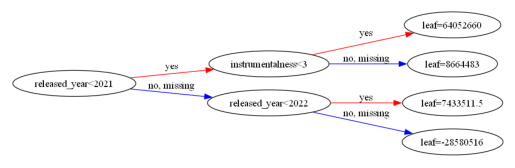

0:[released_year<2021] yes=1,no=2,missing=2
	1:[instrumentalness<3] yes=3,no=4,missing=4
		3:leaf=64052660
		4:leaf=8664483
	2:[released_year<2022] yes=5,no=6,missing=6
		5:leaf=7433511.5
		6:leaf=-28580516



In [66]:
#getting and visualizing the best model
best_model_key = models.loc[models['R2 Score'].idxmax(), 'Model']
best_model = saved_models[best_model_key]

xgb.plot_tree(best_model, tree_idx=0, rankdir='LR')
plt.show()
print(best_model.get_booster().get_dump()[0])  # Print the first tree in the model

Cross-validated R2 scores: [0.24265038 0.45677399 0.3503938  0.40345637 0.40395456 0.51221973
 0.44602477 0.29922793 0.42402356 0.47823849]


Text(0, 0.5, 'R2 Score')

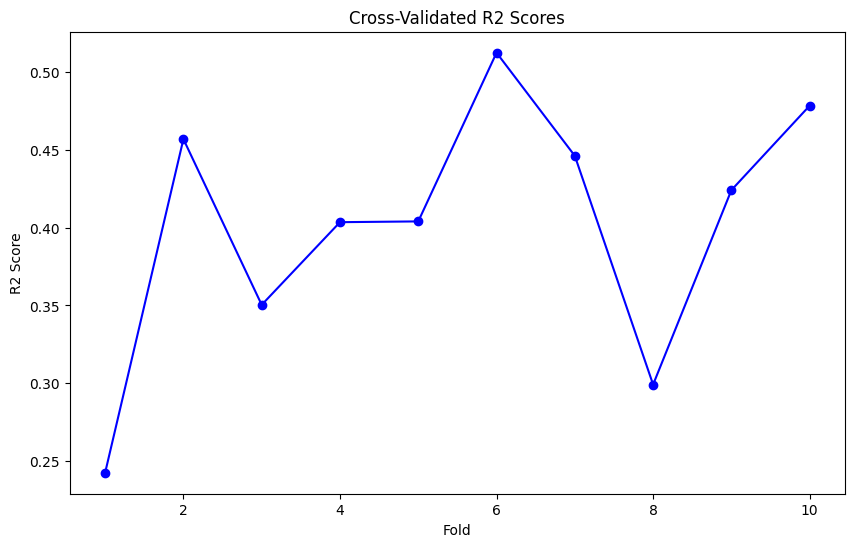

In [67]:
from sklearn.model_selection import cross_val_score, KFold
# Using cross-validation to evaluate the best model adn visualizing r2 scores
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
print(f'Cross-validated R2 scores: {cross_val_scores}')
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cross_val_scores) + 1), cross_val_scores, marker='o', linestyle='-', color='b')
plt.title('Cross-Validated R2 Scores')
plt.xlabel('Fold')
plt.ylabel('R2 Score')

Text(0.5, 1.0, 'Feature Importance')

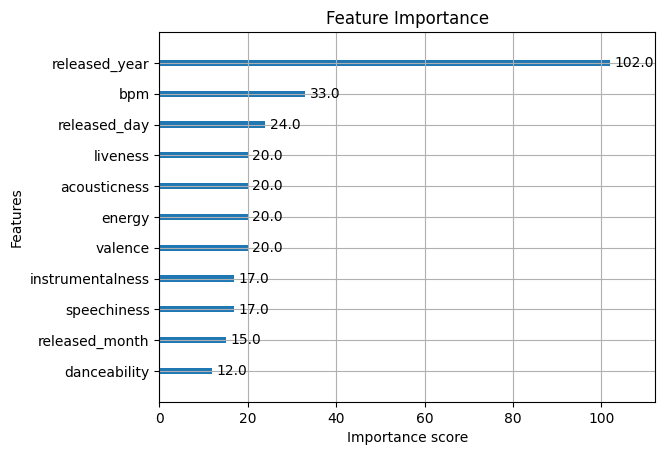

In [68]:
#plotting feature importance
xgb.plot_importance(best_model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')


C:\Users\Liam\AppData\Local\Temp\ipykernel_14888\3339122278.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, stats], ignore_index=True)


    Model           MAE           MSE          RMSE  R2 Score
2  model4  2.373400e+08  1.136980e+17  3.371914e+08  0.386518
0  model2  2.437245e+08  1.367602e+17  3.698110e+08  0.262081
1  model3  2.460687e+08  1.381857e+17  3.717334e+08  0.254389
Cross-validated R2 scores for model4: [0.3217486  0.45657237 0.42561211 0.43458481 0.4245253  0.45076561
 0.38683852 0.30720522 0.41658251 0.37214472]
0:[released_year<2021] yes=1,no=2,missing=2
	1:[released_year<1973] yes=3,no=4,missing=4
		3:[released_year<1968] yes=7,no=8,missing=8
			7:[released_year<1942] yes=15,no=16,missing=16
				15:leaf=-2169005.25
				16:leaf=-897838.125
			8:[released_year<1970] yes=17,no=18,missing=18
				17:leaf=3106640
				18:leaf=-227572.688
		4:[released_year<2020] yes=9,no=10,missing=10
			9:[released_year<2002] yes=19,no=20,missing=20
				19:leaf=4328172.5
				20:leaf=7109607.5
			10:[released_month<11] yes=21,no=22,missing=22
				21:leaf=4754683
				22:leaf=-506226.594
	2:[released_year<2022] yes=5,no=6,mis

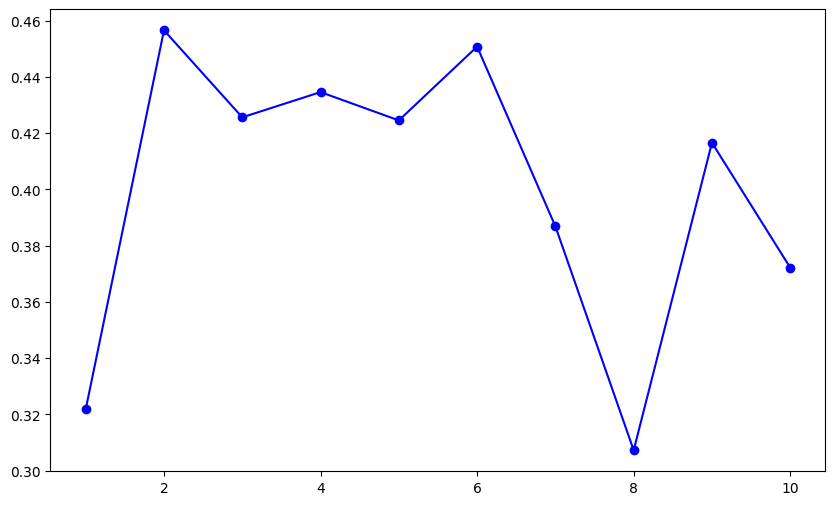

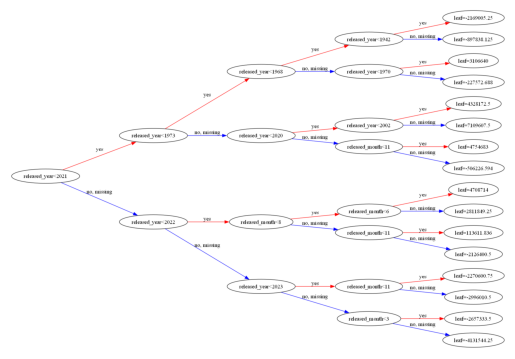

In [69]:
#looking at just year and month for features
#Does year and month matter in vaccuum?
df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce')
df['released_month'] = pd.to_numeric(df['released_month'], errors='coerce')
stats_df = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])
models ={}
X = df[['released_year', 'released_month']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
for branch, lr, est in zip([2,3,4], [0.3, 0.1, 0.01], [50, 100, 150]):
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist', n_estimators= est, learning_rate=lr, max_depth=branch)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    stats = pd.DataFrame({'Model': f'model{branch}',
                             'MAE': sk.metrics.mean_absolute_error(y_test, y_pred_xgb), 
                             'MSE': sk.metrics.mean_squared_error(y_test, y_pred_xgb), 
                             'RMSE': np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_xgb)), 
                             'R2 Score': sk.metrics.r2_score(y_test, y_pred_xgb)}, index=[0])
    stats_df = pd.concat([stats_df, stats], ignore_index=True)
    models[f'model{branch}'] = xgb_model
print(stats_df.sort_values(by='R2 Score', ascending=False))
best_model_name = stats_df.iloc[2,0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
print(f'Cross-validated R2 scores for {best_model_name}: {cross_val_scores}')
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cross_val_scores) + 1), cross_val_scores, marker='o', linestyle='-', color='b')
xgb.plot_tree(best_model, tree_idx=0, rankdir='LR')
print(best_model.get_booster().get_dump()[0])

C:\Users\Liam\AppData\Local\Temp\ipykernel_14888\1493484323.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, stats], ignore_index=True)


    Model           MAE           MSE          RMSE  R2 Score
2  model4  2.362867e+08  1.087995e+17  3.298477e+08  0.412949
1  model3  2.409674e+08  1.277341e+17  3.573991e+08  0.310783
0  model2  2.436765e+08  1.282535e+17  3.581250e+08  0.307981
Cross-validated R2 scores for model4: [0.32531247 0.49323209 0.46987849 0.3909173  0.36818954 0.42546888
 0.42434704 0.30287371 0.42063931 0.449423  ]
0:[released_year<2021] yes=1,no=2,missing=2
	1:[instrumentalness<3] yes=3,no=4,missing=4
		3:[released_year<1975] yes=7,no=8,missing=8
			7:[energy<37] yes=15,no=16,missing=16
				15:leaf=-1867340
				16:leaf=1318621.5
			8:[acousticness<37] yes=17,no=18,missing=18
				17:leaf=5891025
				18:leaf=9411167
		4:[danceability<60] yes=9,no=10,missing=10
			9:[released_month<6] yes=19,no=20,missing=20
				19:leaf=4253262.5
				20:leaf=298272.312
			10:[released_year<2017] yes=21,no=22,missing=22
				21:leaf=-3253605
				22:leaf=1706202.62
	2:[released_year<2022] yes=5,no=6,missing=6
		5:[released_mon

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

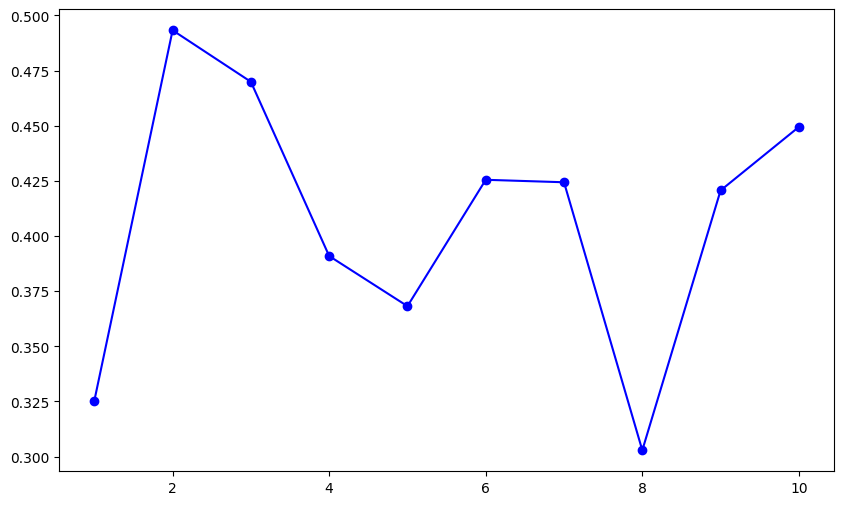

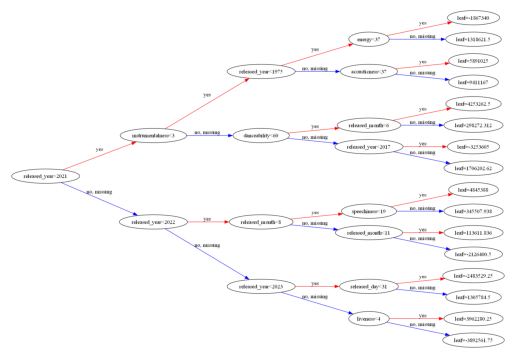

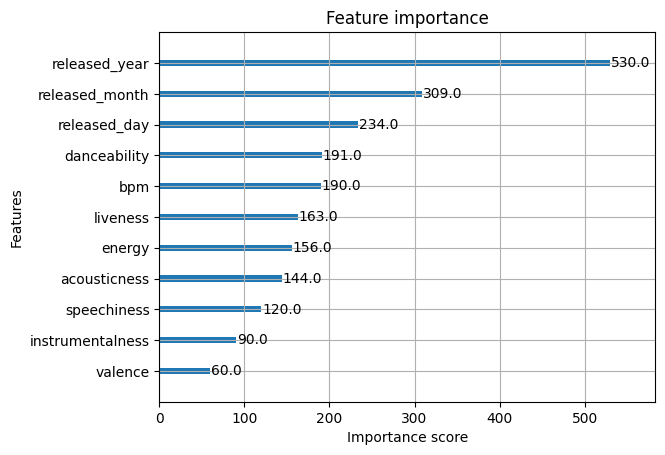

In [70]:
#running hyperparameter tuning and xgboost model with all features
df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce')
df['released_month'] = pd.to_numeric(df['released_month'], errors='coerce')
df['released_day'] = pd.to_numeric(df['released_day'], errors='coerce')
stats_df = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])
models ={}
X = df[['released_year', 'released_month', 'released_day','bpm', 'danceability', 'speechiness', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
for branch, lr, est in zip([2,3,4], [0.3, 0.1, 0.01], [50, 100, 150]):
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist', n_estimators= est, learning_rate=lr, max_depth=branch)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    stats = pd.DataFrame({'Model': f'model{branch}',
                             'MAE': sk.metrics.mean_absolute_error(y_test, y_pred_xgb), 
                             'MSE': sk.metrics.mean_squared_error(y_test, y_pred_xgb), 
                             'RMSE': np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_xgb)), 
                             'R2 Score': sk.metrics.r2_score(y_test, y_pred_xgb)}, index=[0])
    stats_df = pd.concat([stats_df, stats], ignore_index=True)
    models[f'model{branch}'] = xgb_model
print(stats_df.sort_values(by='R2 Score', ascending=False))
best_model_name = stats_df.iloc[2,0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
print(f'Cross-validated R2 scores for {best_model_name}: {cross_val_scores}')
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cross_val_scores) + 1), cross_val_scores, marker='o', linestyle='-', color='b')
xgb.plot_tree(best_model, tree_idx=0, rankdir='LR')
print(best_model.get_booster().get_dump()[0])
xgb.plot_importance(best_model, importance_type='weight', max_num_features=len(X.columns))
#This seems to be producing the best model so far, but still not great.

C:\Users\Liam\AppData\Local\Temp\ipykernel_14888\400736450.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, stats], ignore_index=True)


     Model           MAE           MSE          RMSE  R2 Score
6   model8  2.251683e+08  1.121961e+17  3.349569e+08  0.394622
7   model9  2.244235e+08  1.123717e+17  3.352189e+08  0.393674
5   model7  2.267462e+08  1.135042e+17  3.369038e+08  0.387564
4   model6  2.303021e+08  1.140914e+17  3.377742e+08  0.384395
3   model5  2.302670e+08  1.152794e+17  3.395282e+08  0.377985
2   model4  2.315151e+08  1.160102e+17  3.406027e+08  0.374042
8  model10  2.261631e+08  1.163762e+17  3.411395e+08  0.372068
1   model3  2.338795e+08  1.190853e+17  3.450874e+08  0.357450
0   model2  2.440855e+08  1.264429e+17  3.555880e+08  0.317751


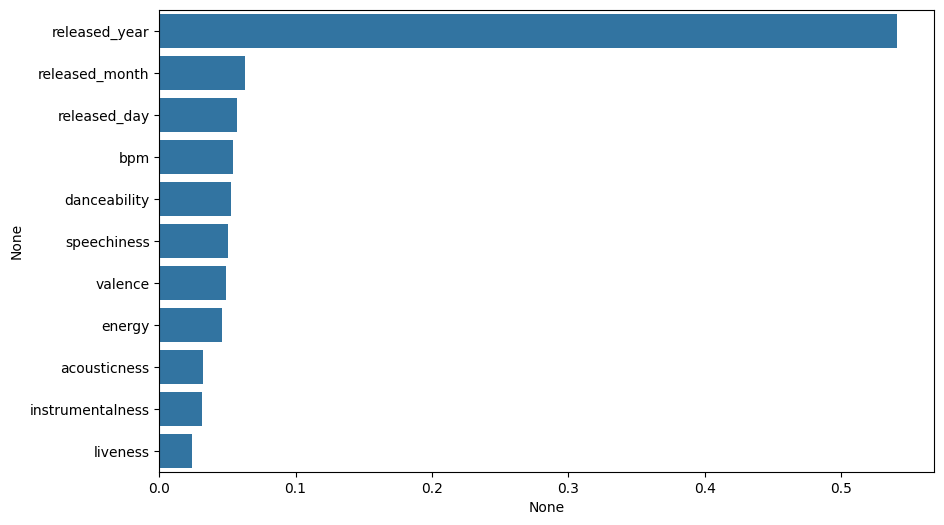

In [85]:
from sklearn.ensemble import RandomForestRegressor
# Using Random Forest Regressor for comparison
X = df[['released_year', 'released_month', 'released_day','bpm', 'danceability', 'speechiness', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness']]
y = df['streams']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
stats_df = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score'])
models = {}
for branch in range(2, 11):
    rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=branch)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    stats = pd.DataFrame({'Model': f'model{branch}',
                             'MAE': sk.metrics.mean_absolute_error(y_test, y_pred_rf), 
                             'MSE': sk.metrics.mean_squared_error(y_test, y_pred_rf), 
                             'RMSE': np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred_rf)), 
                             'R2 Score': sk.metrics.r2_score(y_test, y_pred_rf)}, index=[0])
    stats_df = pd.concat([stats_df, stats], ignore_index=True)
    models[f'model{branch}'] = rf
rf_best_model_name = stats_df.iloc[stats_df['R2 Score'].idxmax(), 0]
rf_best_model = models[rf_best_model_name]
importance = rf_best_model.feature_importances_
importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)   
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=X.columns)
print(stats_df.sort_values(by='R2 Score', ascending=False))



In [ ]:
"""" What we learned:
1. There is a nonlinear relationship between features and target variables. Why Decision tree and random forest models were used.
2. Released year is the most important feature, this was seen both in the ANOVA, decision tree, and random forest models. 
3. Certain decades have higher streams than others, shown in the ANOVA, which is probably why released year is so important.
4. XGBoost and Random Forest models performed similarly, but XGBoost had a slight edge in terms of R2 score. But this has potential for overfitting (even though r2 score was not that high).
5. These features are not be the best for predicting streams, or there is not enough data to accurately uncover patterns. 
6. What I gathered from this analysis:
    Song popularity is influenced by a number of factors, but each decade or time period in which song was released has its own unique characteristics
    these characteristics contribute to the time periods unique sound and style
    therefore, the features that are most important for predicting streams may vary by decade or time period.
7. Future work could include looking at more features, such as genre, artist popularity, and other factors that may influence streams.
   there may be patterns within certain genres the influence popularity that are more consistent. Since certain genres tend to dominate time periods, this may eliminate the over importance of released_year.
"""